Mounted at /content/drive

Final Metrics:


,Model,Accuracy,Precision,Recall,F1-score,AUROC,AUPRC
0,XGBoost,0.874117,0.080682,0.458105,0.137201,0.768945,0.08347


Classification Report:


,precision,recall,f1-score,support
0,0.986484,0.883409,0.932106,106329.000000
1,0.080682,0.458105,0.137201,2375.000000
accuracy,0.874117,0.874117,0.874117,0.874117
macro avg,0.533583,0.670757,0.534653,108704.000000
weighted avg,0.966694,0.874117,0.914738,108704.000000


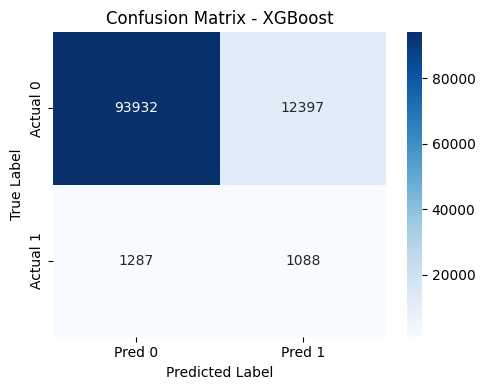

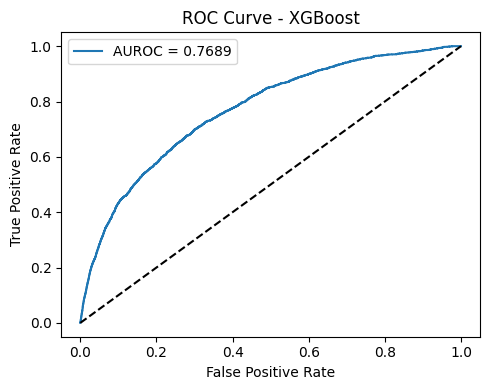

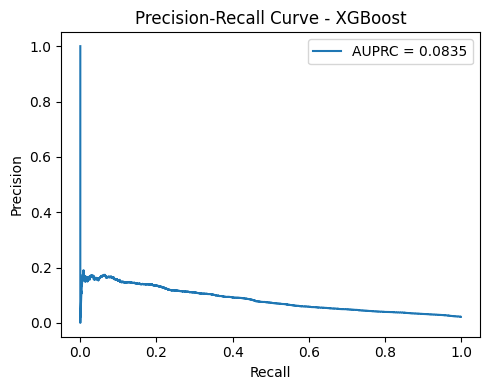

Top Feature Importance:


,Feature,Importance
23,ICULOS,0.154855
21,Unit2,0.095387
20,Unit1,0.082944
3,Temp,0.051510
0,Hour,0.040398
22,HospAdmTime,0.039984
7,Resp,0.038939
13,Lactate,0.038027
9,FiO2,0.036435
11,Creatinine,0.035457


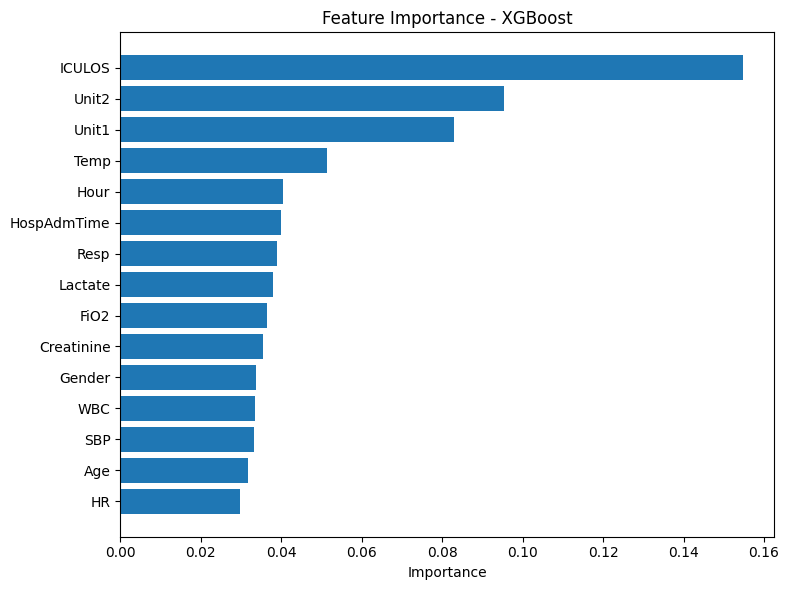


All outputs saved successfully in:
/content/drive/MyDrive/datamining/results/model_3_xgboost

Status marked as DONE.


In [1]:
# ==========================================
# MODEL 3: XGBOOST
# SAVE EVERYTHING TO DRIVE + RESUME SUPPORT
# ==========================================

# 1) Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2) Install if needed
# If xgboost is not installed in your Colab, uncomment the next line:
# !pip install xgboost -q

# 3) Imports
import os
import json
import joblib
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

from xgboost import XGBClassifier

# 4) Paths
base_dir = "/content/drive/MyDrive/datamining"
data_path = os.path.join(base_dir, "Dataset.csv")
save_dir = os.path.join(base_dir, "results", "model_3_xgboost")
os.makedirs(save_dir, exist_ok=True)

status_file = os.path.join(save_dir, "status.txt")

# 5) Skip if already done
if os.path.exists(status_file):
    with open(status_file, "r") as f:
        status = f.read().strip()
    if status == "DONE":
        print("Model 3 already completed. Files are saved in Drive:")
        print(save_dir)
        raise SystemExit

# 6) Load dataset
df = pd.read_csv(data_path)

# 7) Basic cleaning
drop_cols = ["Unnamed: 0", "EtCO2"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

df = df.dropna(subset=["SepsisLabel", "Patient_ID"])
df = df.sort_values(["Patient_ID", "Hour"]).reset_index(drop=True)

# 8) Drop very high missing columns (>90%), but keep some important clinical columns
missing_percent = df.isnull().mean() * 100
important_keep = ["Lactate", "Platelets", "Creatinine", "WBC"]
high_missing_cols = missing_percent[missing_percent > 90].index.tolist()
high_missing_cols = [
    c for c in high_missing_cols
    if c not in important_keep and c not in ["SepsisLabel", "Patient_ID", "Hour"]
]
df = df.drop(columns=high_missing_cols)

# Save dropped column info
pd.DataFrame({"dropped_columns": high_missing_cols}).to_csv(
    os.path.join(save_dir, "dropped_columns.csv"), index=False
)

# 9) Patient-wise forward fill
exclude_ffill = ["SepsisLabel", "Patient_ID", "Hour"]
ffill_cols = [c for c in df.columns if c not in exclude_ffill]
df[ffill_cols] = df.groupby("Patient_ID")[ffill_cols].ffill()

# 10) Feature/target split
target_col = "SepsisLabel"
group_col = "Patient_ID"
feature_cols = [c for c in df.columns if c not in [target_col, group_col]]

# 11) Patient-wise train-test split
patient_df = df[[group_col, target_col]].groupby(group_col)[target_col].max().reset_index()

train_patients, test_patients = train_test_split(
    patient_df,
    test_size=0.2,
    random_state=42,
    stratify=patient_df[target_col]
)

train_ids = set(train_patients[group_col])
test_ids = set(test_patients[group_col])

train_df = df[df[group_col].isin(train_ids)].copy()
test_df  = df[df[group_col].isin(test_ids)].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col].astype(int)

X_test = test_df[feature_cols]
y_test = test_df[target_col].astype(int)

# Save split info
split_info = {
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "train_patients": int(len(train_ids)),
    "test_patients": int(len(test_ids)),
    "n_features": int(len(feature_cols))
}
with open(os.path.join(save_dir, "split_info.json"), "w") as f:
    json.dump(split_info, f, indent=2)

# 12) Imputation
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imp  = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Save preprocessing object
joblib.dump(imputer, os.path.join(save_dir, "imputer.pkl"))

# 13) Compute imbalance weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1.0

# 14) Train XGBoost
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_imp, y_train)

# Save model
joblib.dump(model, os.path.join(save_dir, "xgboost_model.pkl"))

# 15) Predict
y_pred = model.predict(X_test_imp)
y_prob = model.predict_proba(X_test_imp)[:, 1]

# 16) Metrics
acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred, zero_division=0)
rec   = recall_score(y_test, y_pred, zero_division=0)
f1    = f1_score(y_test, y_pred, zero_division=0)
auroc = roc_auc_score(y_test, y_prob)
auprc = average_precision_score(y_test, y_prob)

metrics_df = pd.DataFrame([{
    "Model": "XGBoost",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1-score": f1,
    "AUROC": auroc,
    "AUPRC": auprc
}])

print("\nFinal Metrics:")
display(metrics_df)
metrics_df.to_csv(os.path.join(save_dir, "metrics.csv"), index=False)

# 17) Classification report table
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
print("Classification Report:")
display(report_df)
report_df.to_csv(os.path.join(save_dir, "classification_report.csv"))

# 18) Save predictions
pred_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred,
    "y_prob": y_prob
})
pred_df.to_csv(os.path.join(save_dir, "predictions.csv"), index=False)

# 19) Confusion Matrix plot
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Actual 0", "Actual 1"])
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 20) ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUROC = {auroc:.4f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "roc_curve.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 21) Precision-Recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(5,4))
plt.plot(recall_vals, precision_vals, label=f"AUPRC = {auprc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "pr_curve.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 22) Feature importance
fi_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Top Feature Importance:")
display(fi_df.head(20))
fi_df.to_csv(os.path.join(save_dir, "feature_importance.csv"), index=False)

plt.figure(figsize=(8,6))
top_fi = fi_df.head(15).sort_values("Importance", ascending=True)
plt.barh(top_fi["Feature"], top_fi["Importance"])
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "feature_importance.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 23) Mark as done
with open(status_file, "w") as f:
    f.write("DONE")

print("\nAll outputs saved successfully in:")
print(save_dir)
print("\nStatus marked as DONE.")